# Import

In [43]:
import pandas as pd

import geopandas as gpd
import seaborn as sns

import numpy as np

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt 

from scipy import stats

from shapely import wkt

# Data Wrangling

In [2]:
overlap = gpd.read_file('data\interm\mine_indig_footprint.gpkg')

I had an error in the previouse code. The mine overlay area was only multiplied with 10**-6 however 10**-9 is necessary - > multiply with 10**-3 + rename stuff. 

Consistency check. 

* buffer 0 area mine must be larger or equal then area indig overlap 
* for buffer > larger then the radius

In [3]:
overlap.head()

,ID,area,admin,adm0_a3,list_of_commodities,overlay_area,buffer,max_area,geometry_raw_wkt,geometry
0,23,0.040195,Australia,AUS,Coal,0.040131,0,0.040131,POLYGON ((14729248.192492956 -3395167.12855882...,"POLYGON Z ((14729392.922 -3395167.129 0.000, 1..."
1,30,0.372366,Australia,AUS,"Copper,U3O8,Gold,Zinc,Lead,Silver,Platinum,Nic...",0.065049,0,0.372098,POLYGON ((13644173.133419398 -3875262.58328846...,MULTIPOLYGON Z (((13644203.534 -3875200.456 0....
2,36,0.048309,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.048257,0,0.048257,POLYGON ((13467062.917390855 -3679211.87076415...,"POLYGON Z ((13467053.269 -3679156.546 0.000, 1..."
3,37,0.242487,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.242234,0,0.242234,POLYGON ((13464911.27334126 -3680594.910173434...,"POLYGON Z ((13465345.462 -3679101.220 0.000, 1..."
4,38,0.172674,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.172483,0,0.172483,POLYGON ((13464785.841176935 -3671541.18209177...,"POLYGON Z ((13465248.975 -3671541.182 0.000, 1..."


In [5]:
subset = overlap[['ID', 'buffer', 'overlay_area', 'max_area']]
subset['difference'] = subset['max_area'] - subset['overlay_area']

C:\Users\admin\AppData\Local\Temp\ipykernel_28676\3094148999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['difference'] = subset['max_area'] - subset['overlay_area']


In [6]:
subset.difference.describe()

count    8.336800e+04
mean     2.447253e+03
std      2.826796e+03
min     -1.273293e-11
25%      1.364242e-12
50%      1.323934e+03
75%      4.292047e+03
max      2.857551e+04
Name: difference, dtype: float64

In [8]:
subset[subset.difference < 0].count() / subset.shape[0]	

ID              0.103877
buffer          0.103877
overlay_area    0.103877
max_area        0.103877
difference      0.103877
dtype: float64

For approximately 10% of the overlays is the overlay area bigger then the max area theoretically possible fo rthe overlay. Therefore an messurement error. Next question how big this measurement error is. 

In [9]:
subset ['rel_difference']  = subset['difference'] / subset['max_area'] 

C:\Users\admin\AppData\Local\Temp\ipykernel_28676\3914386984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset ['rel_difference']  = subset['difference'] / subset['max_area']


<Axes: xlabel='rel_difference', ylabel='Count'>

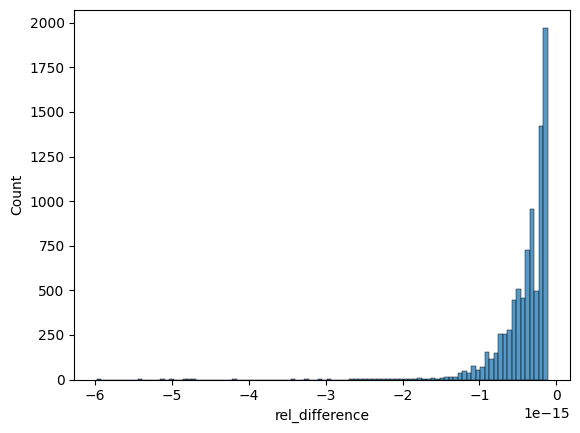

In [11]:
sns.histplot(subset[subset.difference < 0]['rel_difference'], bins = 100)

We can already visually assess that if the highest frequencies (probabilities) are around very small relative difference values. Lets confirm this in a hypothesis test.

In [12]:
subset.columns

Index(['ID', 'buffer', 'overlay_area', 'max_area', 'difference',
       'rel_difference'],
      dtype='object')

In [17]:
sub_group = subset[subset.difference < 0].groupby('buffer')

In [34]:
# Perform a one-sample t-test
# Null hypothesis: mean(delta_0_relative) >= 1%
# Alternative hypothesis: mean(delta_0_relative) < 1%
collect = {'buffer': [],'sample_size':[], 't_stat': [], 'p_value': [], 'reject_null': []}

for name, group in sub_group:

    delta_rel_abs = abs(group['rel_difference'])
    t_stat, p_value = stats.ttest_1samp(delta_rel_abs, .01, alternative='less')

      
    alpha = 0.01
    if p_value < alpha:
        reject_null = True
       
    else:
        reject_null = False
        
    collect['buffer'].append(name)
    collect['t_stat'].append(t_stat)
    collect['p_value'].append(p_value)
    collect['reject_null'].append(reject_null)
    collect['sample_size'].append(group.shape[0])

df = pd.DataFrame(collect)



In [35]:
df

,buffer,sample_size,t_stat,p_value,reject_null
0,0,3751,-1.465819e+15,0.0,True
1,10,2725,-1.978442e+15,0.0,True
2,30,1301,-1.459334e+15,0.0,True
3,50,883,-1.470414e+15,0.0,True


How to interpret this:

* for all overlays we can be confident that in 99 of 100 cases if the difference is negative it will be relative to the maximum possible area small <1%
* As a result we are justified in substitutin for this cases the maximum area with the higher overlay area. And further substitute the geometry.


In [36]:
df.to_latex('tabs\mine_indig_footprint_ttest.tex')

In [37]:
overlap.columns

Index(['ID', 'area', 'admin', 'adm0_a3', 'list_of_commodities', 'overlay_area',
       'buffer', 'max_area', 'geometry_raw_wkt', 'geometry'],
      dtype='object')

In [45]:
overlap['geometry_raw_wkt'] = overlap['geometry_raw_wkt'].apply(wkt.loads) 

In [46]:
overlap['difference'] = overlap['max_area'] - overlap['overlay_area']

In [49]:
def overlay_adjust(row):
    if row['difference'] < 0:
        return row['geometry_raw_wkt'], row['max_area']
    else:
        return row['geometry'], row['overlay_area']

overlap['geometry'], overlap['overlay_area'] = zip(*overlap.apply(overlay_adjust, axis=1))

In [54]:
assert all(overlap.overlay_area <= overlap.overlay_area.max())

we can conclude that the probability that for buffer one the deviation relative to the mine area of the overlay is smaller than 1 percent is 93% this means most of the overlap calculation vary only very minor from the max of the mining area. 

# Clean up a bit


In [58]:
overlap.set_index('ID', inplace=True)

In [60]:
overlap.rename(columns = {'area': 'mine_area','max_area': 'max_buffered_area'}, inplace=True)

In [62]:
overlap.drop(columns = ['geometry_raw_wkt', 'difference'], inplace=True)

In [74]:
overlap.to_file('data\interm\mine_indig_footprint_corrected.gpkg', driver='GPKG')

,mine_area,admin,adm0_a3,list_of_commodities,overlay_area,buffer,max_buffered_area,geometry
ID,,,,,,,,
392,0.090845,Algeria,DZA,"Gold,Silver,U3O8",0.090845,0,0.090596,"POLYGON Z ((238832.490 2632053.158 0.000, 2385..."
393,0.014823,Algeria,DZA,"Gold,Silver,U3O8",0.014823,0,0.014782,"POLYGON Z ((240607.837 2633400.432 0.000, 2405..."
395,0.015353,Algeria,DZA,Gold,0.015353,0,0.015312,"POLYGON Z ((249783.682 2685806.051 0.000, 2498..."
1759,0.193727,Algeria,DZA,Gold,0.193251,0,0.193251,"POLYGON ((529299.612 2842355.717, 529411.439 2..."
1760,0.287636,Algeria,DZA,Gold,0.286869,0,0.286869,"POLYGON ((249094.577 2687764.046, 249144.268 2..."
...,...,...,...,...,...,...,...,...
66239,0.029152,Algeria,DZA,Zinc,0.029152,50,7875.049180,"POLYGON Z ((-177968.070 4158383.074 0.000, -17..."
66240,0.220359,Algeria,DZA,Zinc,0.220359,50,7941.164051,"POLYGON Z ((-182009.818 4181837.405 0.000, -18..."
66381,1.134019,Algeria,DZA,Iron Ore,1.134019,50,8049.468644,"POLYGON Z ((782964.642 4248827.242 0.000, 7779..."
